In [13]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt # data visualization
import seaborn as sns # statistical data visualization
from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split,cross_val_score,KFold,GridSearchCV

In [8]:
# ignore warnings
import warnings
warnings.filterwarnings("ignore")

### Reading dataset

In [2]:
df = pd.read_csv('Breast_cancer_data.csv')

### Viewing summary of the dataset

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   mean_radius      569 non-null    float64
 1   mean_texture     569 non-null    float64
 2   mean_perimeter   569 non-null    float64
 3   mean_area        569 non-null    float64
 4   mean_smoothness  569 non-null    float64
 5   diagnosis        569 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 26.8 KB


In [4]:
df.isna().sum()

mean_radius        0
mean_texture       0
mean_perimeter     0
mean_area          0
mean_smoothness    0
diagnosis          0
dtype: int64

In [5]:
df.describe()

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,diagnosis
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,1.000000


In [6]:
df.head()

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0
1,20.57,17.77,132.90,1326.0,0.08474,0
2,19.69,21.25,130.00,1203.0,0.10960,0
3,11.42,20.38,77.58,386.1,0.14250,0
4,20.29,14.34,135.10,1297.0,0.10030,0


### Distribution of the target variable

In [9]:
# check the distribution of the target variable
df['diagnosis'].value_counts()

diagnosis
1    357
0    212
Name: count, dtype: int64

### Features and target variable

In [10]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

In [11]:
lgbm = LGBMClassifier()
lgbm.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 249, number of negative: 149
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000120 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 665
[LightGBM] [Info] Number of data points in the train set: 398, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.625628 -> initscore=0.513507
[LightGBM] [Info] Start training from score 0.513507
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

LGBMClassifier()

In [12]:
pred = lgbm.predict(X_test)
pred

array([1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1])

In [14]:
accuracy = accuracy_score(pred, y_test)
print('LightGBM Model accuracy score: {0:0.4f}'.format(accuracy_score(y_test, pred)))

LightGBM Model accuracy score: 0.9064


In [16]:
y_pred_train = lgbm.predict(X_train)

### Compare train and test set accuracy

In [17]:
print('Training-set accuracy score: {0:0.4f}'. format(accuracy_score(y_train, y_pred_train)))

Training-set accuracy score: 1.0000


### Checking for overfitting

In [19]:
# print the scores on training and test set

print('Training set score: {:.4f}'.format(lgbm.score(X_train, y_train)))

print('Test set score: {:.4f}'.format(lgbm.score(X_test, y_test)))

Training set score: 1.0000
Test set score: 0.9064


### Confusion-matrix

In [21]:
# view confusion-matrix
# Print the Confusion Matrix and slice it into four pieces

from sklearn.metrics import confusion_matrix
conf_mat = confusion_matrix(y_test, pred)
print('Confusion matrix\n', conf_mat)
print('\nTrue Positives(TP) = ', conf_mat[0,0])
print('\nTrue Negatives(TN) = ', conf_mat[1,1])
print('\nFalse Positives(FP) = ', conf_mat[0,1])
print('\nFalse Negatives(FN) = ', conf_mat[1,0])

Confusion matrix
 [[ 53  10]
 [  6 102]]

True Positives(TP) =  53

True Negatives(TN) =  102

False Positives(FP) =  10

False Negatives(FN) =  6


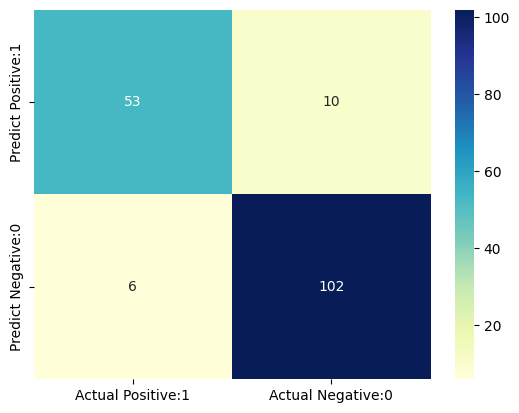

In [22]:
# visualize confusion matrix with seaborn heatmap

cm_matrix = pd.DataFrame(data= conf_mat, columns=['Actual Positive:1', 'Actual Negative:0'], 
                                 index=['Predict Positive:1', 'Predict Negative:0'])

sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='YlGnBu')
plt.show()

### Classification Report

In [23]:
from sklearn.metrics import classification_report
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.90      0.84      0.87        63
           1       0.91      0.94      0.93       108

    accuracy                           0.91       171
   macro avg       0.90      0.89      0.90       171
weighted avg       0.91      0.91      0.91       171



## LightGBM Parameter Tuning
Table of Contents

In this section are some tips to improve LightGBM model efficiency.

Following set of practices can be used to improve your model efficiency.

1 num_leaves : This is the main parameter to control the complexity of the tree model. Ideally, the value of num_leaves should be less than or equal to 2^(max_depth). Value more than this will result in overfitting.

2 min_data_in_leaf : Setting it to a large value can avoid growing too deep a tree, but may cause under-fitting. In practice, setting it to hundreds or thousands is enough for a large dataset.

3 max_depth : We also can use max_depth to limit the tree depth explicitly.


### For Faster Speed
1.Use bagging by setting bagging_fraction and bagging_freq.\
2.Use feature sub-sampling by setting feature_fraction. \
3.Use small max_bin.\
4.Use save_binary to speed up data loading in future learning.


### For better accuracy
1.Use large max_bin (may be slower).\
2.Use small learning_rate with large num_iterations\
3.Use large num_leaves(may cause over-fitting)\
4.Use bigger training data\
5.Try dart\
6.Try to use categorical feature directly.


### To deal with over-fitting
1.Use small max_bin\
2.Use small num_leaves\
3.Use min_data_in_leaf and min_sum_hessian_in_leaf\
4.Use bagging by set bagging_fraction and bagging_freq\
5.Use feature sub-sampling by set feature_fraction\
6.Use bigger training data\
7.Try lambda_l1, lambda_l2 and min_gain_to_split to regularization\
8.Try max_depth to avoid growing deep tree